In [1]:
import numpy as np
import tensorflow as tf # budowanie modelu
import cv2 # do przetwarzania obrazu i uczenia maszynowego
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [2]:
# with_info - dodatkowa krotka z informacjami o wersji, funkcjach, liczbie próbek
# as supervised - True daje zestaw danych w postaci input, target    False daje słownik
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

# wyodrębnienie zestawu danych szkoleniowych i testowych
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# zdefiniowanie liczby próbek walidacyjnych jako % próbek trenujących
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples

# konwersja na int
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

# zmienna z liczbą próbek testowych
num_test_samples = mnist_info.splits['test'].num_examples

# konwersja na int
num_test_samples = tf.cast(num_test_samples, tf.int64)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.LPLSVR_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.LPLSVR_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [3]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255. # podzielenie przez 255 aby otrzymać wartość 0-1
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)

test_data = mnist_test.map(scale)

In [5]:
# ilosć próbek przechowywanych w pamięci na raz
BUFFER_SIZE = 1000

# tasowanie danych w buforze
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

# pobrane danej ilości próbek
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)

# pomijamy próbki walidacyjne
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [6]:
# wielkość partii podawanej podczas trenowania
BATCH_SIZE = 100

# tworzenie partii danych testowych
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

# iteracja przez partię walidacyjną
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [8]:
input_size = 784 # 28x28 px -> 784
output_size = 10 # 10 różnych cyfr 0-9

# rozmiar ukrytej warstwy
hidden_layer_size = 50

model = tf.keras.Sequential([
    # warstwa wejściowa z próbkami o rozmiarze 28x28x1
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),

    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),

    # warstwa wyjściowa
    tf.keras.layers.Dense(hidden_layer_size, activation='softmax'),
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
NUM_EPOCHS = 30 # ilość epok

# mechanzim wczesnego zatrzymywania w celu ochrony przed przetenowaniem
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data, # dane wejściowe trenujące
          epochs=NUM_EPOCHS, # maksymalna ilość epok
          callbacks=[early_stopping], # mechanizm wczesnego zatrzymywania
          validation_data=(validation_inputs, validation_targets), # dane walidacyjne
          verbose = 1
         )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8598 - loss: 0.5279 - val_accuracy: 0.9307 - val_loss: 0.2376
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9427 - loss: 0.1992 - val_accuracy: 0.9447 - val_loss: 0.1818
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9550 - loss: 0.1545 - val_accuracy: 0.9562 - val_loss: 0.1511
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9621 - loss: 0.1274 - val_accuracy: 0.9600 - val_loss: 0.1379
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9679 - loss: 0.1084 - val_accuracy: 0.9617 - val_loss: 0.1314
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9721 - loss: 0.0951 - val_accuracy: 0.9573 - val_loss: 0.1363
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9757 - loss: 0.0837 - val_accuracy: 0.9608 - val_loss: 0.1271
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9784 - loss: 0.0731 - val_accuracy

In [11]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9686 - loss: 0.1087
Test loss: 0.11. Test accuracy: 96.86%


## Zadanie

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Przewidziana cyfra:  0
Pewność:  0.9318326


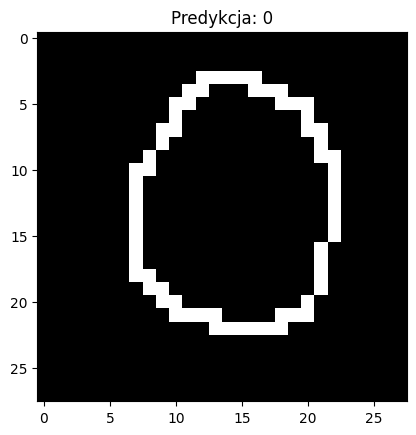

In [28]:
img = cv2.imread("/content/0.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Przewidziana cyfra:  1
Pewność:  0.66066045


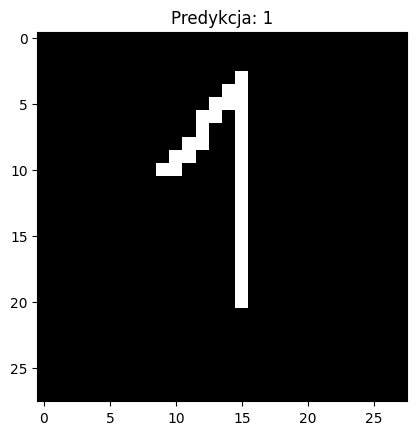

In [29]:
img = cv2.imread("/content/1.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Przewidziana cyfra:  2
Pewność:  0.91059875


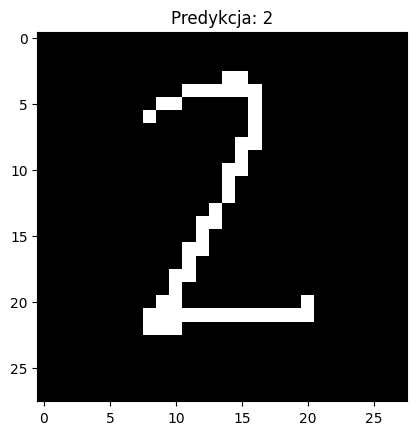

In [30]:
img = cv2.imread("/content/2.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Przewidziana cyfra:  3
Pewność:  0.8852418


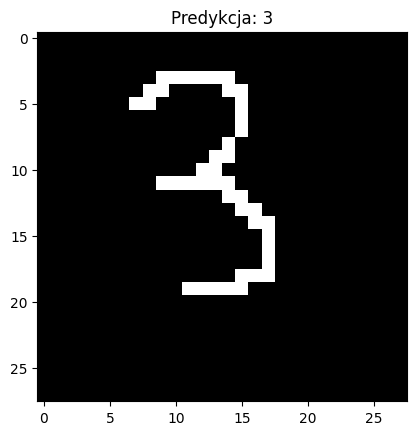

In [31]:
img = cv2.imread("/content/3.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Przewidziana cyfra:  4
Pewność:  0.94322836


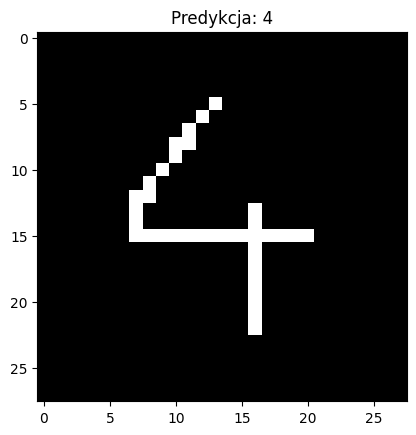

In [32]:
img = cv2.imread("/content/4.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Przewidziana cyfra:  5
Pewność:  0.89417654


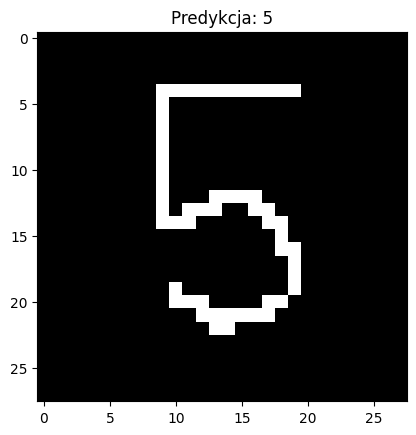

In [33]:
img = cv2.imread("/content/5.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Przewidziana cyfra:  6
Pewność:  0.6901192


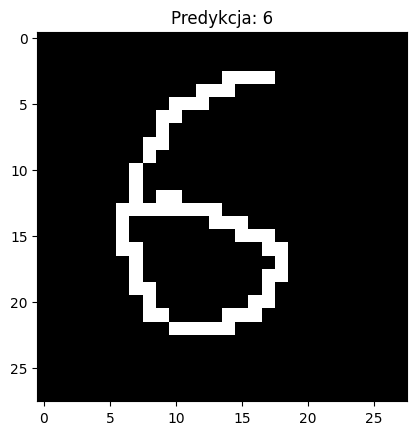

In [34]:
img = cv2.imread("/content/6.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Przewidziana cyfra:  3
Pewność:  0.98500097


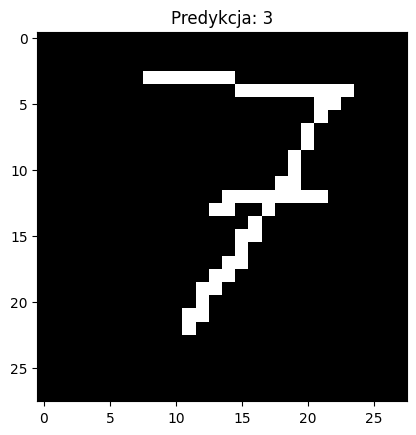

In [35]:
img = cv2.imread("/content/7.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Przewidziana cyfra:  3
Pewność:  0.99358845


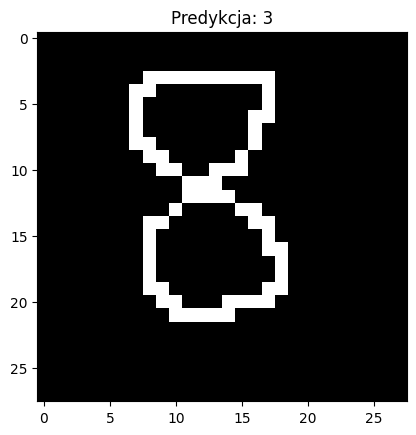

In [36]:
img = cv2.imread("/content/8.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Przewidziana cyfra:  3
Pewność:  0.8097567


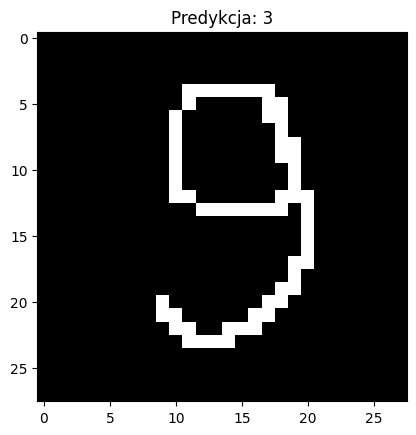

In [37]:
img = cv2.imread("/content/9.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Przewidziana cyfra:  5
Pewność:  0.99102634


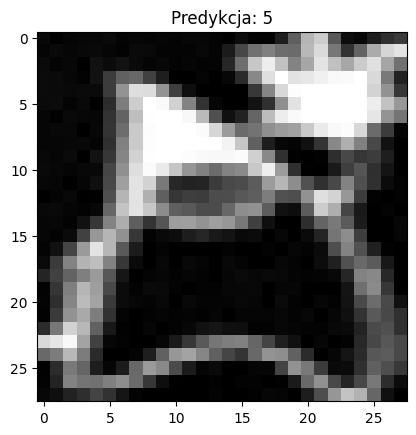

In [38]:
img = cv2.imread("/content/duke_inverted.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# normalizacja (0-1)
img = img.astype(np.float32) / 255.

# reshape do formatu (1, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

predictions = model.predict(img)

predicted_digit = np.argmax(predictions)

print("Przewidziana cyfra: ", predicted_digit)
print("Pewność: ", np.max(predictions))

# podgląd obrazu
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predykcja: {predicted_digit}")
plt.show()